# Accessing Spectral Analysis datasets from Project Pythia's Object Storage on Jetstream2

#### Imports

In [1]:
import s3fs
import xarray as xr

Create S3 filesystem

In [2]:
URL = 'https://js2.jetstream-cloud.org:8001/' #Locate and read a file
fs = s3fs.S3FileSystem(anon=True, client_kwargs=dict(endpoint_url=URL))

Create mappers to the Zarr stores

In [3]:
hgt_200_store = s3fs.S3Map(
    root=f'pythia/hgt_200hPa-ncep-ncar.zarr',
    s3=fs,
    check=False
)

Create Xarray Datasets

In [4]:
# Open with xarray
hgt_200 = xr.open_zarr(hgt_200_store)
hgt_200

<xarray.Dataset> Size: 247MB
Dimensions:  (time: 17167, lat: 25, lon: 144)
Coordinates:
  * time     (time) datetime64[ns] 137kB 1979-01-01 1979-01-02 ... 2025-12-31
  * lat      (lat) float32 100B 30.0 27.5 25.0 22.5 ... -22.5 -25.0 -27.5 -30.0
  * lon      (lon) float32 576B 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
    level    float32 4B ...
Data variables:
    hgt      (time, lat, lon) float32 247MB dask.array<chunksize=(1024, 25, 144), meta=np.ndarray>

Repeat for the next three variables.

In [5]:
olr_noaa_store = s3fs.S3Map(
    root=f'pythia/olr_noaa.zarr',
    s3=fs,
    check=False
)

# Open with xarray


In [6]:
# Open with xarray
olr_noaa = xr.open_zarr(olr_noaa_store)
olr_noaa = olr_noaa.rename_vars({'__xarray_dataarray_variable__': 'olr'})

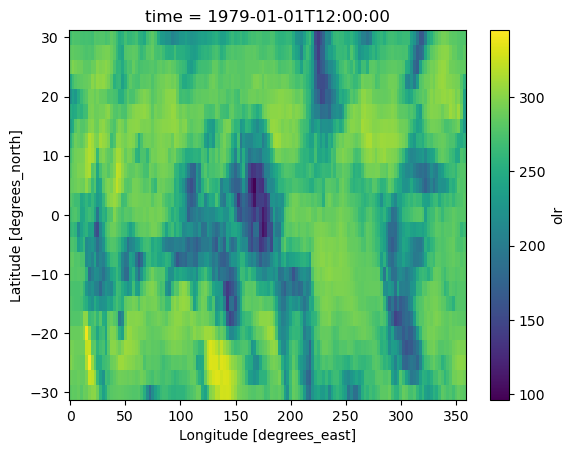

In [7]:
olr_noaa['olr'][0].plot()

In [8]:
sst_noaa_oi_store = s3fs.S3Map(
    root=f'pythia/sst_noaa_oi.zarr',
    s3=fs,
    check=False
)

In [14]:
# Open with xarray
sst_noaa_oi = xr.open_zarr(sst_noaa_oi_store)
sst_noaa_oi = sst_noaa_oi.rename_vars({'__xarray_dataarray_variable__': 'sst'})
sst_noaa_oi

<xarray.Dataset> Size: 233MB
Dimensions:  (time: 16193, lat: 25, lon: 144)
Coordinates:
  * time     (time) datetime64[ns] 130kB 1981-09-01 1981-09-02 ... 2025-12-31
  * lat      (lat) float32 100B 30.0 27.5 25.0 22.5 ... -22.5 -25.0 -27.5 -30.0
  * lon      (lon) float32 576B 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
Data variables:
    sst      (time, lat, lon) float32 233MB dask.array<chunksize=(1024, 25, 144), meta=np.ndarray>

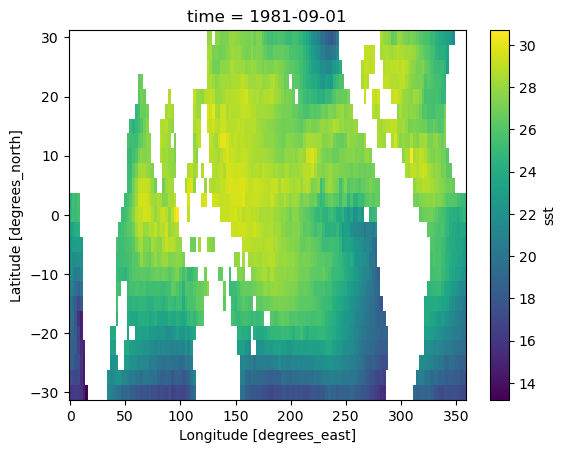

In [15]:
sst_noaa_oi['sst'][0].plot()

In [10]:
uwind_ncep_ncar_store = s3fs.S3Map(
    root=f'pythia/uwind-ncep-ncar.zarr',
    s3=fs,
    check=False
)

In [11]:
# Open with xarray
uwind_ncep_ncar = xr.open_zarr(uwind_ncep_ncar_store)
uwind_ncep_ncar

<xarray.Dataset> Size: 495MB
Dimensions:  (time: 17167, level: 2, lat: 25, lon: 144)
Coordinates:
  * time     (time) datetime64[ns] 137kB 1979-01-01 1979-01-02 ... 2025-12-31
  * level    (level) float32 8B 850.0 200.0
  * lat      (lat) float32 100B 30.0 27.5 25.0 22.5 ... -22.5 -25.0 -27.5 -30.0
  * lon      (lon) float32 576B 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
Data variables:
    uwnd     (time, level, lat, lon) float32 494MB dask.array<chunksize=(1024, 2, 25, 144), meta=np.ndarray>

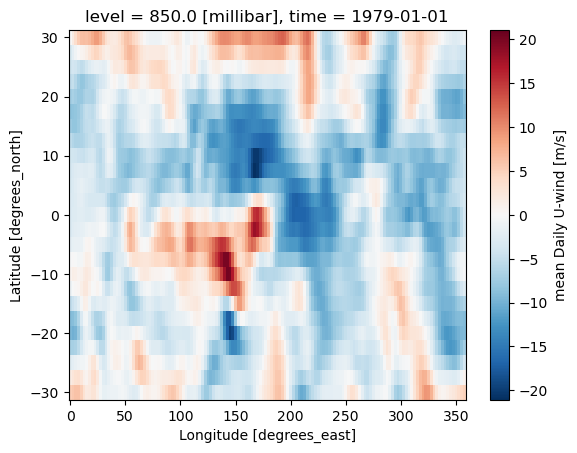

In [12]:
uwind_ncep_ncar.uwnd.isel(level=0, time=0).plot()